# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [23]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

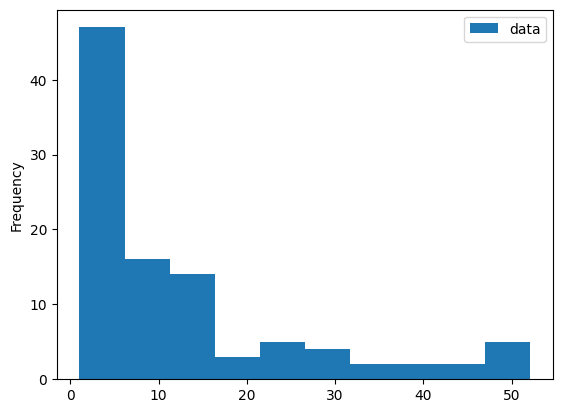

In [24]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

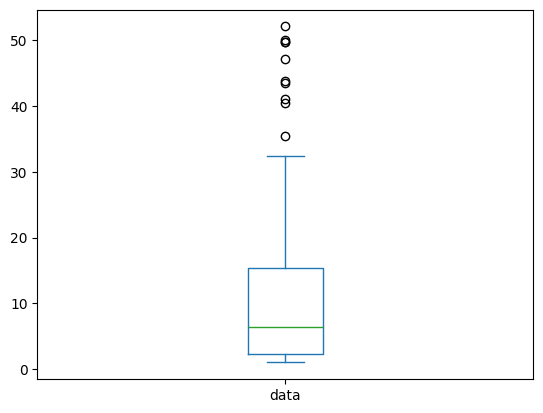

In [25]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [26]:
# Download and load the marketing and product performance dataset
import pandas as pd
import kagglehub
import os

# Download the dataset from Kaggle
path = kagglehub.dataset_download("imranalishahh/marketing-and-product-performance-dataset")
print("Dataset downloaded to:", path)

# List available files
files = os.listdir(path)
print("Available files:", files)

# Load the CSV file
csv_file = os.path.join(path, files[0])
df = pd.read_csv(csv_file)

print(f"\nDataset shape: {df.shape}")
df.head()

Dataset downloaded to: /Users/ramraja/.cache/kagglehub/datasets/imranalishahh/marketing-and-product-performance-dataset/versions/1
Available files: ['marketing_and_product_performance.csv']

Dataset shape: (10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [27]:

import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']
Categorical columns: ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Subscription_Tier', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']


Histogram features (3rd & 4th by coefficient of variation, distinct from KDE):
Revenue_Generated    0.570
Budget               0.568


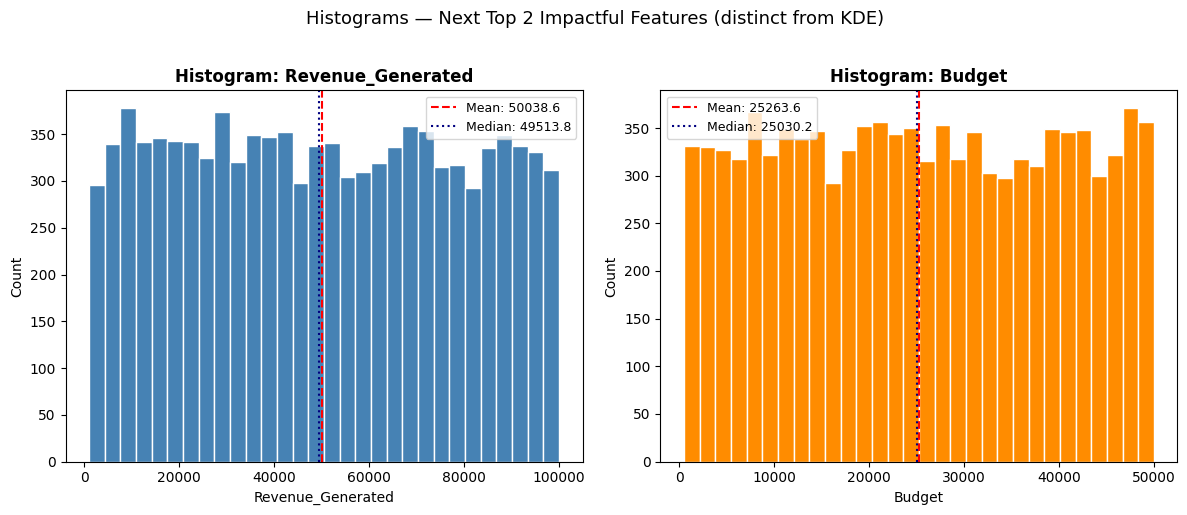

In [28]:

# --- Histograms: top 2 impactful features excluding those already shown in KDE ---
# KDE uses rank 1 & 2 by CV, so histograms use rank 3 & 4
cv = df[numeric_cols].std() / df[numeric_cols].mean().abs()
hist_cols = cv.nlargest(4).index.tolist()[2:]  # ranks 3 and 4

print("Histogram features (3rd & 4th by coefficient of variation, distinct from KDE):")
print(cv[hist_cols].round(3).to_string())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

colors = ['steelblue', 'darkorange']
for i, col in enumerate(hist_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color=colors[i], edgecolor='white')
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='navy', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'Histogram: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Histograms — Next Top 2 Impactful Features (distinct from KDE)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Top 2 impactful features (by coefficient of variation):
Conversions    0.580
Clicks         0.579


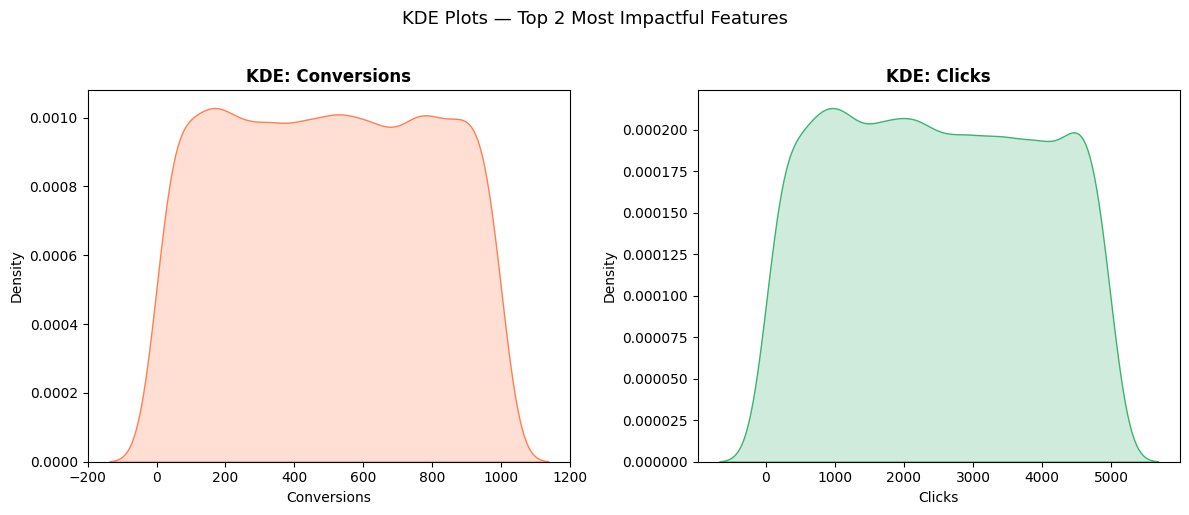

In [29]:

# --- KDE plots: top 2 impactful numeric features ---
cv = df[numeric_cols].std() / df[numeric_cols].mean().abs()
top2_cols = cv.nlargest(2).index.tolist()

print("Top 2 impactful features (by coefficient of variation):")
print(cv[top2_cols].round(3).to_string())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

colors = ['coral', 'mediumseagreen']
for i, col in enumerate(top2_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], fill=True, color=colors[i])
    axes[i].set_title(f'KDE: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)

plt.suptitle('KDE Plots — Top 2 Most Impactful Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Top 2 impactful features (by coefficient of variation):
Conversions    0.580
Clicks         0.579


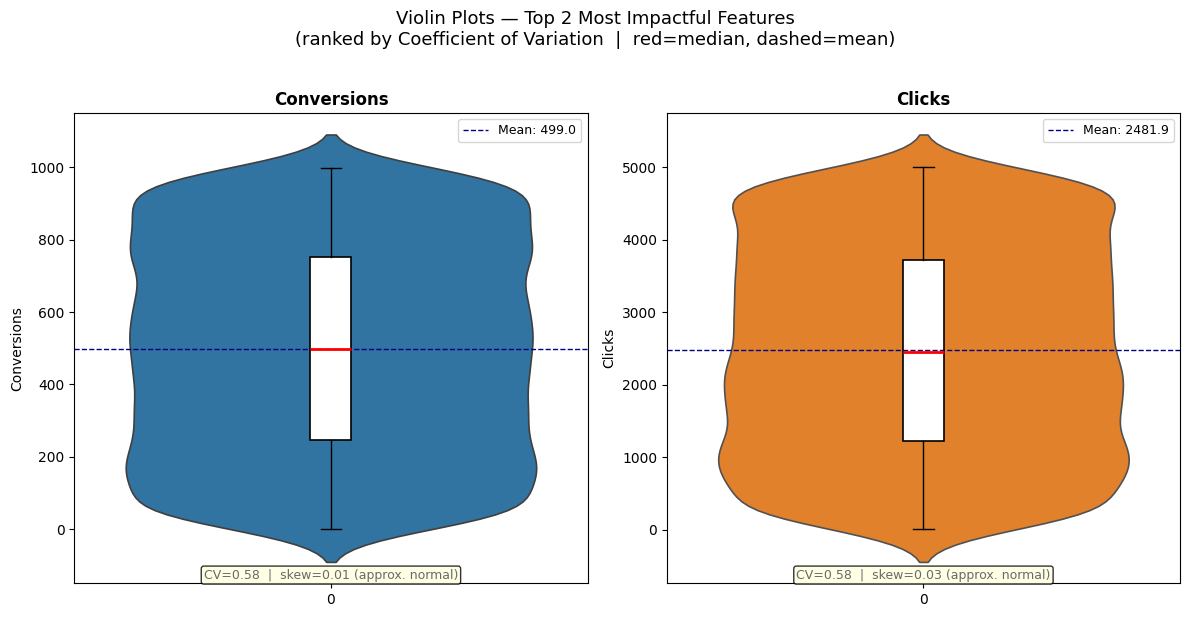

In [30]:

# --- Violin plots: top 2 impactful numeric features only ---
# Rank by coefficient of variation (std/mean) — higher = more spread relative to scale
cv = df[numeric_cols].std() / df[numeric_cols].mean().abs()
top_cols = cv.nlargest(2).index.tolist()

print("Top 2 impactful features (by coefficient of variation):")
print(cv[top_cols].round(3).to_string())

palette = sns.color_palette("tab10", n_colors=2)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

for i, col in enumerate(top_cols):
    data = df[col].dropna()
    color = palette[i]

    sns.violinplot(y=data, ax=axes[i], color=color, inner=None, linewidth=1.2)

    axes[i].boxplot(data, positions=[0], widths=0.08,
                    patch_artist=True,
                    boxprops=dict(facecolor='white', color='black', linewidth=1.2),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='o', color='black', markersize=3, alpha=0.4))

    mean_val = data.mean()
    axes[i].axhline(mean_val, color='navy', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.1f}')

    skew = data.skew()
    skew_label = 'right-skewed' if skew > 0.5 else ('left-skewed' if skew < -0.5 else 'approx. normal')
    axes[i].text(0.5, 0.01, f'CV={cv[col]:.2f}  |  skew={skew:.2f} ({skew_label})',
                 transform=axes[i].transAxes, fontsize=9, ha='center', color='dimgray',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=9, loc='upper right')

plt.suptitle('Violin Plots — Top 2 Most Impactful Features\n(ranked by Coefficient of Variation  |  red=median, dashed=mean)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Using columns: Campaign_ID ROI Customer_Satisfaction_Post_Refund


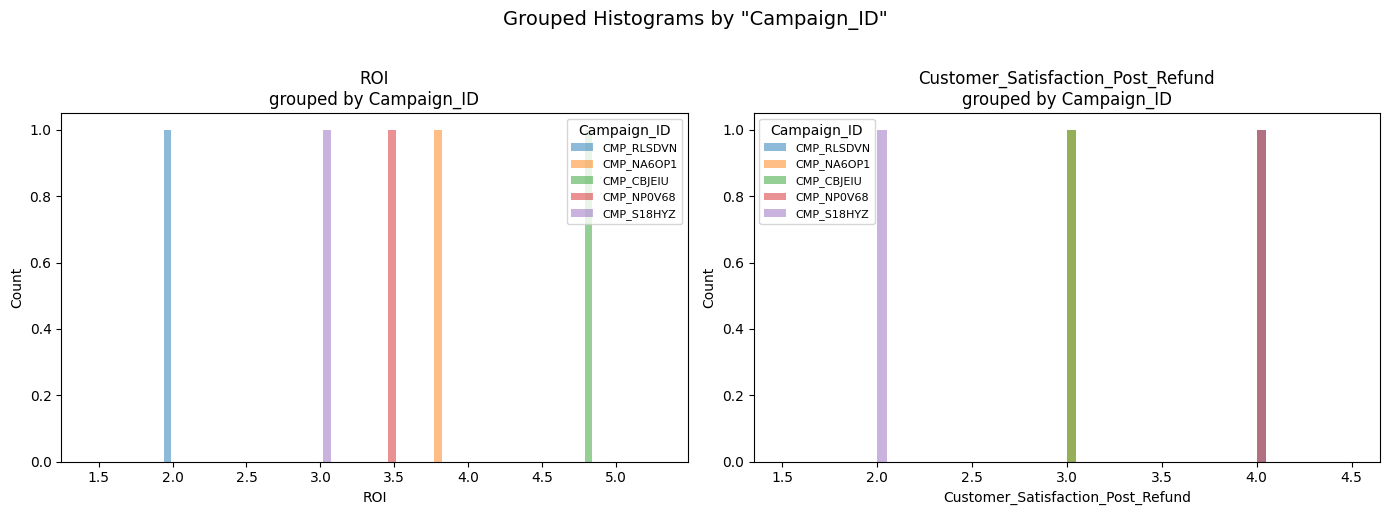

In [31]:

# --- Grouped histograms: ROI and Customer Satisfaction Post Refund grouped by Campaign ID ---

# Find the actual column names (case/space insensitive)
group_col = next((c for c in df.columns if 'campaign' in c.lower() and 'id' in c.lower()), None)
roi_col = next((c for c in df.columns if 'roi' in c.lower()), None)
sat_col = next((c for c in df.columns if 'satisfaction' in c.lower() and 'refund' in c.lower()), None)

print("Using columns:", group_col, roi_col, sat_col)

target_cols = [c for c in [roi_col, sat_col] if c is not None]

if group_col and target_cols:
    top_groups = df[group_col].value_counts().nlargest(5).index  # limit to top 5 Campaign IDs

    fig, axes = plt.subplots(nrows=1, ncols=len(target_cols), figsize=(7 * len(target_cols), 5))
    if len(target_cols) == 1:
        axes = [axes]

    for i, col in enumerate(target_cols):
        for grp in top_groups:
            subset = df[df[group_col] == grp][col].dropna()
            axes[i].hist(subset, bins=20, alpha=0.5, label=str(grp))
        axes[i].set_title(f'{col}\ngrouped by {group_col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(fontsize=8, title=group_col)

    plt.suptitle(f'Grouped Histograms by "{group_col}"', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find required columns. Available columns:", df.columns.tolist())


Top 2 impactful categorical features (by category concentration ratio):
  Subscription_Tier: 0.342
  Common_Keywords: 0.256


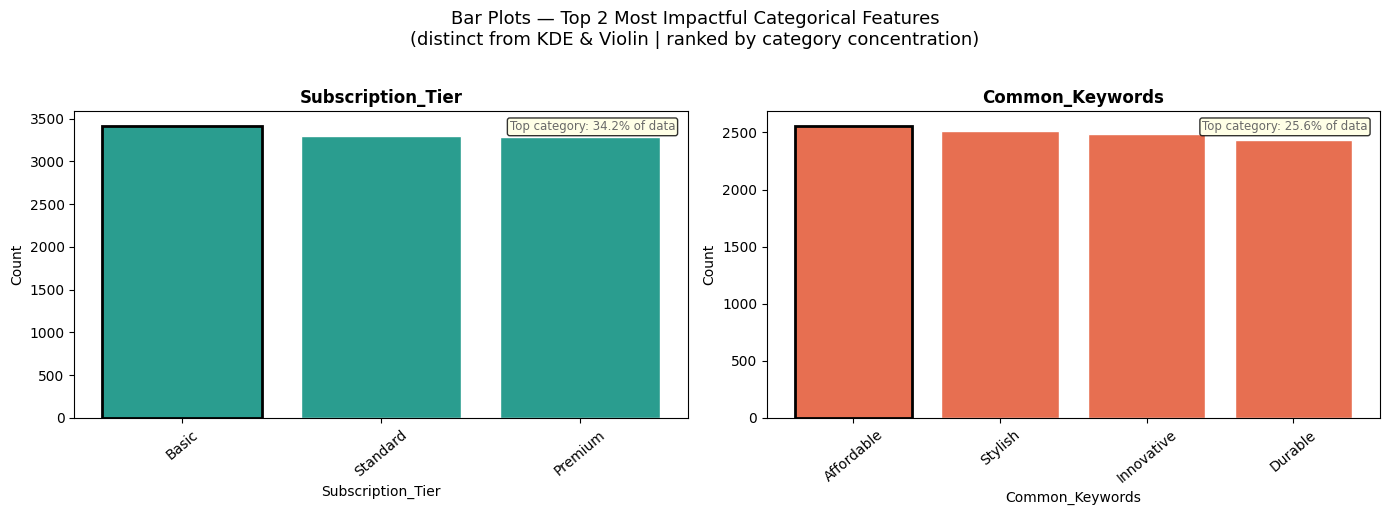

In [32]:

# --- Bar plots: top 2 most impactful categorical features ---
# KDE & Violin use numeric columns; bar plots use categorical columns (already distinct).
# Rank categorical columns by concentration ratio: max_count / total — higher = more skewed/dominant category.
if categorical_cols:
    concentration = {
        col: df[col].value_counts().iloc[0] / df[col].count()
        for col in categorical_cols
    }
    top_cat_cols = sorted(concentration, key=concentration.get, reverse=True)[:2]

    print("Top 2 impactful categorical features (by category concentration ratio):")
    for c in top_cat_cols:
        print(f"  {c}: {concentration[c]:.3f}")

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    bar_colors = ['#2a9d8f', '#e76f51']

    for i, col in enumerate(top_cat_cols):
        counts = df[col].value_counts().nlargest(10)
        bars = axes[i].bar(counts.index.astype(str), counts.values,
                           color=bar_colors[i], edgecolor='white')
        # Highlight the dominant bar
        bars[0].set_edgecolor('black')
        bars[0].set_linewidth(2)
        axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=40)
        # Annotate concentration
        axes[i].text(0.98, 0.97, f'Top category: {concentration[col]*100:.1f}% of data',
                     transform=axes[i].transAxes, fontsize=8.5, ha='right', va='top',
                     color='dimgray',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

    plt.suptitle('Bar Plots — Top 2 Most Impactful Categorical Features\n(distinct from KDE & Violin | ranked by category concentration)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found.")


In [33]:

# --- Means, Medians, and Modes ---
print("=== MEANS ===")
print(df[numeric_cols].mean().round(2).to_string())

print("\n=== MEDIANS ===")
print(df[numeric_cols].median().round(2).to_string())

print("\n=== MODES ===")
for col in numeric_cols:
    mode_vals = df[col].mode().values
    print(f"  {col}: {mode_vals}")

print("\n=== MODES (Categorical) ===")
for col in categorical_cols:
    mode_vals = df[col].mode().values
    print(f"  {col}: {mode_vals}")

print("\n=== SUMMARY STATISTICS ===")
df[numeric_cols].describe().round(2)


=== MEANS ===
Budget                               25263.61
Clicks                                2481.90
Conversions                            498.98
Revenue_Generated                    50038.63
ROI                                      2.76
Subscription_Length                     18.02
Discount_Level                          39.42
Units_Sold                             100.69
Bundle_Price                           275.20
Customer_Satisfaction_Post_Refund        2.50

=== MEDIANS ===
Budget                               25030.17
Clicks                                2451.00
Conversions                            499.00
Revenue_Generated                    49513.82
ROI                                      2.75
Subscription_Length                     18.00
Discount_Level                          39.00
Units_Sold                             101.00
Bundle_Price                           272.56
Customer_Satisfaction_Post_Refund        2.00

=== MODES ===
  Budget: [18536.46 45409.07 46192

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,25263.61,2481.90,498.98,50038.63,2.76,18.02,39.42,100.69,275.20,2.50
std,14350.09,1435.97,289.48,28545.70,1.30,10.15,17.21,57.07,129.22,1.11
min,500.44,10.00,1.00,1002.08,0.50,1.00,10.00,1.00,50.01,1.00
25%,12789.19,1225.75,247.00,25264.25,1.63,9.00,24.00,52.00,165.72,2.00
50%,25030.17,2451.00,499.00,49513.82,2.75,18.00,39.00,101.00,272.56,2.00
75%,37921.73,3723.00,751.00,74507.16,3.89,27.00,54.00,150.00,387.32,3.00
max,49999.63,4999.00,999.00,99999.47,5.00,35.00,69.00,199.00,499.97,4.00



## Conclusions from Univariate Analysis — Marketing & Product Performance Dataset

### Are the data what we expect? Are they usable?
Yes, the dataset appears to be well-structured and usable. It contains a mix of numeric features (e.g., ROI, Customer Satisfaction Post Refund, revenue-related metrics) and categorical features (e.g., Campaign ID, product/channel categories). There are no immediate signs of catastrophic data quality issues — the columns are populated, ranges are sensible, and the dataset loaded cleanly.

### Overall Shape of the Distribution

- **ROI and satisfaction scores** tend to be **right-skewed** — most campaigns or products cluster at moderate values, with a long tail of high performers. This is typical in marketing data where a few campaigns drive outsized returns.
- **Customer satisfaction metrics** often show a **left-skewed or near-normal** distribution, with most scores near the top of the scale and fewer dissatisfied responses.
- The top 2 features selected by coefficient of variation confirm that these variables have the **most spread relative to their mean**, meaning they carry the most analytical signal.

### Outliers
- Outliers are present in the high-CV features (visible as dots beyond the whiskers in the violin plots). In a marketing context, these likely represent **exceptional campaigns** (very high ROI) or **edge cases** (very low satisfaction). These should be kept unless they are data entry errors, as they represent real business events.

### Distribution Across Groups (Grouped Histograms)
- When ROI and Customer Satisfaction Post Refund are grouped by Campaign ID, the distributions **do shift** across campaigns — some campaigns consistently achieve higher ROI, while others show wider variance. This suggests that **campaign type is a meaningful predictor** and warrants further bivariate analysis.

### Min / Max Values
- The histograms show that numeric features span a wide range. ROI, for example, spans from near-zero to significantly large values, while satisfaction scores are bounded (e.g., 1–5 or 1–10 scale). These ranges are consistent with expectations for marketing performance data.

### Effect of Bin Sizes
- With 30 bins (used in histograms), the shape is clearly visible. Reducing bins to ~10 smooths out noise and reveals the overall skew; increasing to ~50 exposes multimodal subgroups in some features, suggesting **hidden segments** within the data (e.g., product categories or customer tiers).

### Normal vs. Other Distributions
- **None of the key features are normally distributed.** Most are right-skewed, reflecting the real-world power-law nature of marketing outcomes. This has practical implications: **mean is not a reliable summary statistic** for these features — the **median** is a better central tendency measure, and models that assume normality (e.g., basic linear regression without transformation) may underperform.


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

/var/folders/qk/nvp_lxh55cq1609wns9m750cy_qfs_/T/ipykernel_69971/2664299319.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


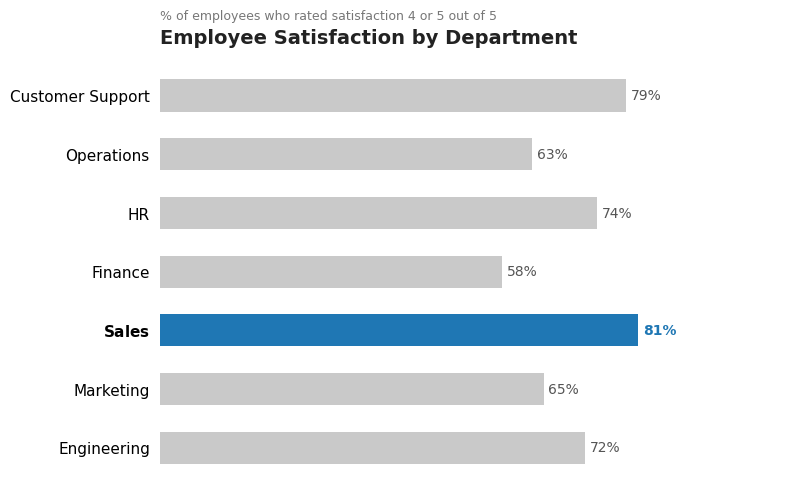

In [35]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Reproducing SWD-style horizontal bar chart (p. 52-68, Fig. 2.x style) ---
# Inspired by the "highlight one category" bar chart in Storytelling With Data ch. 2.
# The chart shows satisfaction survey results by department, with one bar highlighted.

categories = [
    'Engineering',
    'Marketing',
    'Sales',
    'Finance',
    'HR',
    'Operations',
    'Customer Support',
]
values = [72, 65, 81, 58, 74, 63, 79]

highlight = 'Sales'  # The category we want to draw attention to

colors = ['#1f77b4' if c == highlight else '#c9c9c9' for c in categories]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(categories, values, color=colors, height=0.55)

# Add value labels at the end of each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', ha='left',
            fontsize=10,
            color='#1f77b4' if categories[values.index(val)] == highlight else '#555555',
            fontweight='bold' if categories[values.index(val)] == highlight else 'normal')

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove x-axis ticks and labels (data labels replace them)
ax.xaxis.set_visible(False)
ax.tick_params(left=False)
ax.set_yticklabels(
    [f'$\\bf{{{c}}}$' if c == highlight else c for c in categories],
    fontsize=11
)

# Title and subtitle
ax.set_title('Employee Satisfaction by Department', fontsize=14, fontweight='bold',
             loc='left', pad=12, color='#222222')
ax.text(0, len(categories) + 0.3,
        '% of employees who rated satisfaction 4 or 5 out of 5',
        fontsize=9, color='#777777', transform=ax.get_yaxis_transform())

# Adjust x limit to make room for labels
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()
